# `cavity_theory` Example Notebook

This notebook provides a practical introduction to the `cavity_theory` class and demonstrates its main features through a typical workflow.

The examples presented here are intended to help you get started quickly. They are **not** an exhaustive overview of every feature or configuration supported by the class. Instead, they focus on the core functionality and the most common usage patterns, which should cover around **99% of everyday use cases**.

For more advanced applications or specialized configurations, please refer to the class documentation.

`cavity_theory` computes the resonance frequencies of TM and TE modes in a cylindrical cavity as a function of its length, identifies mode crossings, and plots mode diagrams. It relies on the zeros of Bessel functions to derive the resonance frequencies.

## Initialization

Parameters of the initialization:

| Parameter | Type | Description |
|---|---|---|
| `radius` | `float` | Cavity radius in mm |
| `lengths` | `np.ndarray` | Array of cavity lengths to sweep (mm) |
| `freq_window` | `np.ndarray` | Frequency range `[fmin, fmax]` in GHz |
| `data` | object | Optional pandas DataFrame with `length` and `freq` columns. Overrides `lengths` and `freq_window` if provided |
| `nmax` | `int` | Maximum azimuthal mode index n (default: 5) |
| `lmax` | `int` | Maximum radial mode index l (default: 5) |
| `mmax` | `int` | Maximum longitudinal mode index m (default: 9) |
****
> Either `data` **or** both `lengths` and `freq_window` must be provided.

In [7]:
from microwave_cavity import cavity_theory
import numpy as np

thmodes = cavity_theory(
    radius = 25,                            # Cavity radius in mm
    lengths = np.linspace(63, 113, 50),     # Cavity lengths in mm
    freq_window = (4, 8),                   # Frequency window in GHz
    data = None,                            # External data (useless if length and freq_windows are provided)
)

## Methods

### Compute the TE and TM modes

Computes all TM and TE resonant frequencies for the given parameter ranges. Results are stored in `self.dict_modes` as `{mode_label: [(length, freq), ...]}`.

Mode labels follow the convention `TM{n}{l}{m}` or `TE{n}{l}{m}`.

In [8]:
# To compute the modes

thmodes.compute_modes()     # No parameter for this function

### Crossing modes

In some cases, you may want to compute only TEM modes far from a crossing. You can also to the opposite and compute TEM modes near a crossing.

Both of these functions need `compute_modes` to be called before.

Two points are considered neighbors when their normalized distance in the `(length, frequency)` space is smaller than one.

To parametrize a crossing:

| Parameter | Type | Description |
|---|---|---|
| `threshold_length` | `float` | Length normalization scale in mm (default = 2) |
| `threshold_freq` | `float` | Frequency normalization scale in GHz (default = 50e-3) |
| `min_modes` | `float` | Minimum number of distinct modes locally present for a point to be classified as part of a crossing. (default = 2) |

In [9]:
# To compute modes near a crossing
thmodes.crossing_modes()                # Only optional parameters for this function

# To compute modes far from a crossing
thmodes.non_crossing_modes()            # Only optional parameters for this function

### Plots

This functions is to plot the computed modes.

TE modes plotted in one color, and TM modes in an other color. By default, the x-axis is the cavity lengths and the y-axis is the frequencies.

Mode labels are also shown helping the identification of each branche.

Parameters:

| Parameter | Type | Description |
|---|---|---|
| `crossing` | `bool` | If `None`: plot all computed modes. If `True`: plot only crossing points. If `False`: plot only non-crossing points. (default is `None`) |
| `inverted_axis` | `bool` | If `True`, swap the frequency and length axes. (default is `False`) |
| `colors` | `list` |Colors used for TE and TM modes, respectively. (default = `['blue', 'red']`) |
| `used_dict` | `dict` | Dictionary of modes to plot. If not provided, it is selected automatically according to the value of `crossing`. (default = `None`) |

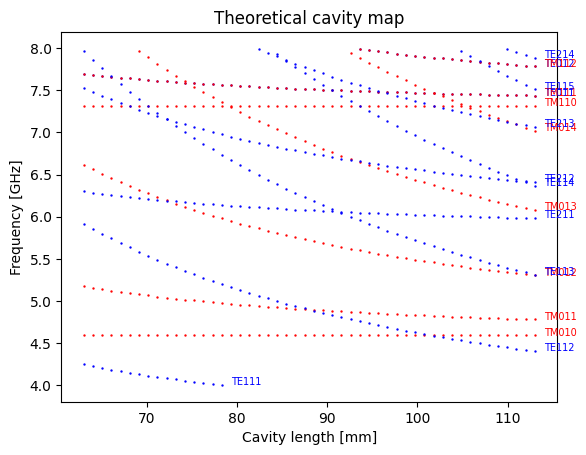

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
thmodes.plot_modes(ax=ax, marker='.', s=2)
ax.set_xlabel("Cavity length [mm]")
ax.set_ylabel('Frequency [GHz]')
ax.set_title('Theoretical cavity map')
plt.show()

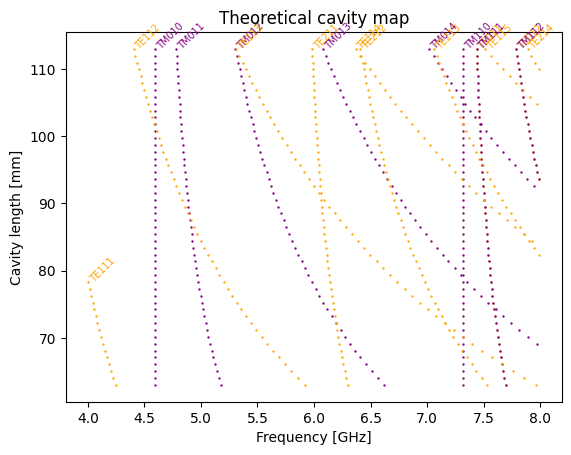

In [11]:
fig, ax = plt.subplots()
thmodes.plot_modes(colors=['orange', 'purple'], inverted_axis=True, ax=ax, marker='.', s=2)
ax.set_xlabel('Frequency [GHz]')
ax.set_ylabel("Cavity length [mm]")
ax.set_title('Theoretical cavity map')
plt.show()

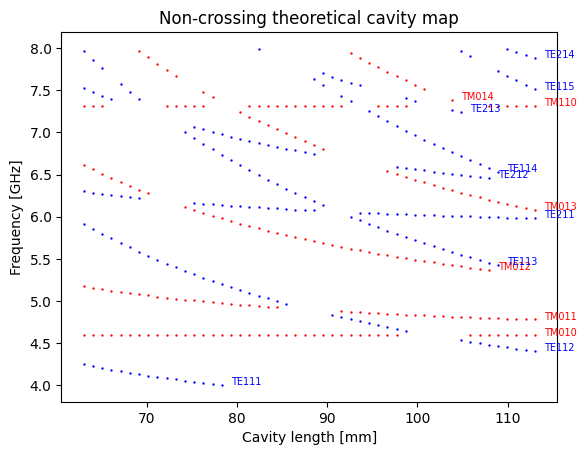

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
thmodes.plot_modes(crossing=False, ax=ax, marker='.', s=2)
ax.set_xlabel("Cavity length [mm]")
ax.set_ylabel('Frequency [GHz]')
ax.set_title('Non-crossing theoretical cavity map')
plt.show()